# Unified Pipeline Validation

Run the unified grism pipeline on a single SCA and visually validate:
1. Full detector overview
2. Bright star and galaxy cutouts
3. Star vs galaxy morphology comparison
4. Extracted 1D spectrum vs expected (input SED × sensitivity × dlam)

In [1]:
import subprocess
import sys
from pathlib import Path

# Add project root to path so we can import from scripts/
PROJECT_ROOT = Path("../..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import yaml
from astropy.io import fits
from matplotlib.colors import AsinhNorm
import pyarrow.parquet as pq

import jax.numpy as jnp
import roman_disperser.optical_model_jax as omj
from roman_disperser.optical_model import RomanOpticalModel
from roman_disperser.pipeline import load_sensitivities, resolve_paths

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Run the pipeline

In [2]:
# Configuration
POINTING_RA = 10.0
POINTING_DEC = 0.0
POINTING_PA = 0.0
SCA = 5
SEED = 42
ORDER = "1"  # Primary order for spectral extraction

OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_STEM = f"validate_sca{SCA}"
OUTPUT_FITS = OUTPUT_DIR / f"{OUTPUT_STEM}.fits"

In [3]:
# Run the pipeline
cmd = [
    sys.executable, "../../scripts/build_grism_image.py",
    "--pointing-ra", str(POINTING_RA),
    "--pointing-dec", str(POINTING_DEC),
    "--pointing-pa", str(POINTING_PA),
    "--sca", str(SCA),
    "--seed", str(SEED),
    "--output", str(OUTPUT_FITS),
    "--force",
]
print("Running:", " ".join(cmd))
result = subprocess.run(cmd, capture_output=False)
result.check_returncode()
print("\nDone.")

Running: /home/np274/projects/roman_disperser/.pixi/envs/cuda/bin/python ../../scripts/build_grism_image.py --pointing-ra 10.0 --pointing-dec 0.0 --pointing-pa 0.0 --sca 5 --seed 42 --output data/validate_sca5.fits --force
Loading catalog...
  98013 sources (87039 stars, 10974 galaxies) in 0.02s
Validating catalog...
Wavelength grid: 0.9-2.0 um, 2.0 A spacing, 5501 samples
Loading star SED templates...
  24 templates, 0.5 MB in 0.00s
Loading optical model...
Setting up 1 SCAs...
  PSF oversample: 4x, galaxy image: 30px native = 120px oversampled

  SCA 5 (WFI05):
    PSF payloads loaded

JIT warmup (compiling all SCA/order dispersers)...
  SCA 5 star  order 0: 2.4s
  SCA 5 star  order 1: 2.3s
  SCA 5 star  order 2: 2.3s
  SCA 5 galaxy order 0: 2.7s
  SCA 5 galaxy order 1: 2.5s
  SCA 5 galaxy order 2: 2.5s
  Total warmup: 14.8s

Setup complete in 17.4s

Pointing: RA=10.0, Dec=0.0, PA=0.0
Output:   data/.tmp_sca5
  Cone search...
    27854 sources within 0.6 deg in 0.01s
    24624 stars,

    I/O: transfer 0.04s, FITS 0.09s, PNG 0.23s
    Total: 12.13s, flux=8.9490e+05, peak=1.9587e+02

  Source manifest: 1969 rows -> data/.tmp_sca5/grism_.tmp_sca5_sources.parquet

  Pointing complete in 14.3s

Done.


## 2. Load outputs

In [4]:
# Load FITS
with fits.open(OUTPUT_FITS) as hdul:
    header = hdul[0].header
    model = hdul["MODEL"].data.astype(np.float32)
    isim = hdul["ISIM"].data.astype(np.float32)

print(f"MODEL: shape={model.shape}, flux={model.sum():.4e}, peak={model.max():.4e}")
print(f"ISIM:  shape={isim.shape}, counts={isim.sum():.4e}")

# Load manifest
manifest_path = OUTPUT_DIR / f"{OUTPUT_STEM}_sources.parquet"
manifest = pq.read_table(manifest_path).to_pandas()
print(f"\nManifest: {len(manifest)} rows")
print(manifest.groupby(["order", "type"]).size().unstack(fill_value=0))

# Load meta
meta_path = OUTPUT_DIR / f"{OUTPUT_STEM}_meta.yaml"
with open(meta_path) as f:
    meta_yaml = yaml.safe_load(f)

MODEL: shape=(4088, 4088), flux=8.9490e+05, peak=1.9587e+02
ISIM:  shape=(4088, 4088), counts=1.7025e+08

Manifest: 1969 rows
type   PSF  SER
order          
0      443   96
1      559  103
2      663  105


## 3. Full detector overview

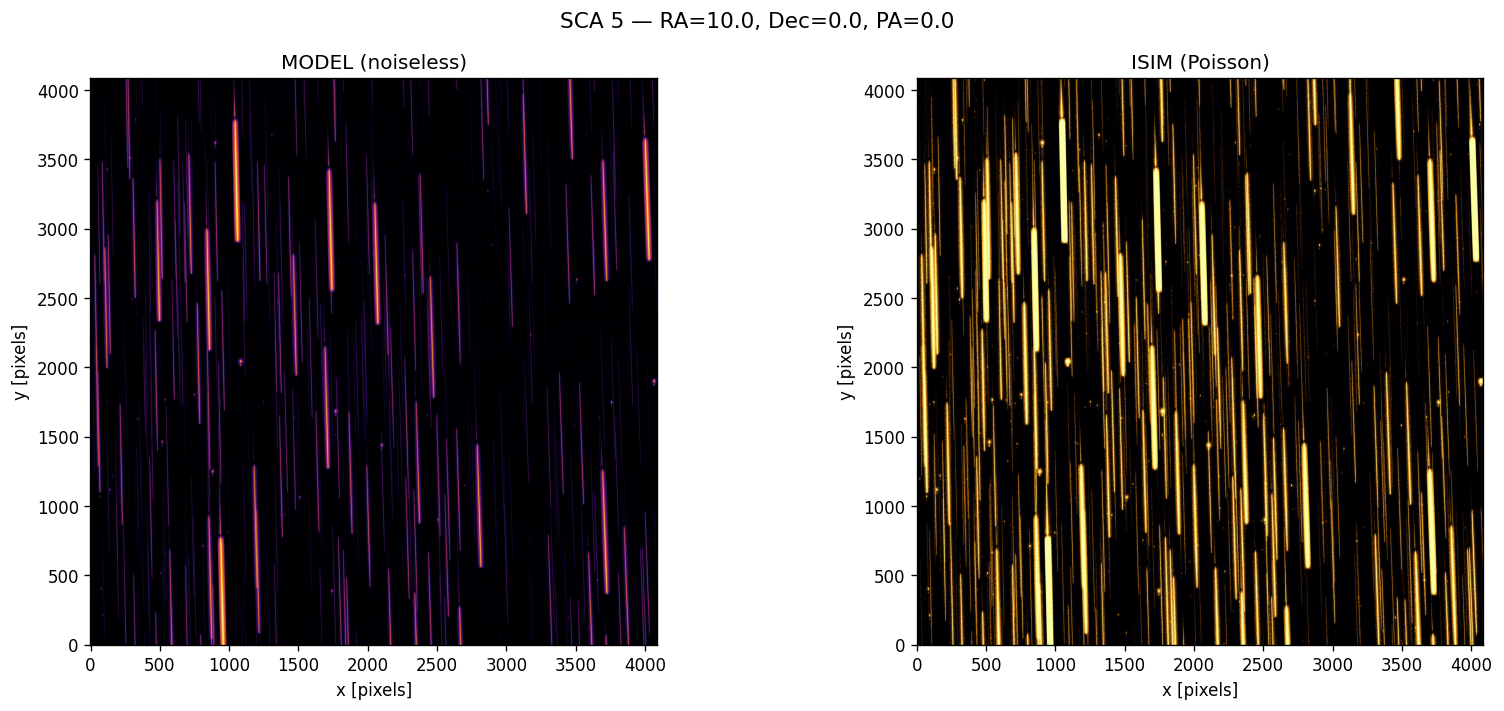

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

vmax = np.percentile(model[model > 0], 99.9) if model.max() > 0 else 1.0
norm = AsinhNorm(linear_width=0.01, vmin=0, vmax=vmax)

for ax, data, title in zip(axes, [model, isim], ["MODEL (noiseless)", "ISIM (Poisson)"]):
    ax.imshow(data, origin="lower", cmap="inferno", norm=norm)
    ax.set_title(title)
    ax.set_xlabel("x [pixels]")
    ax.set_ylabel("y [pixels]")

fig.suptitle(f"SCA {SCA} — RA={POINTING_RA}, Dec={POINTING_DEC}, PA={POINTING_PA}",
             fontsize=13)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{OUTPUT_STEM}_overview.png", dpi=150)
plt.show()

## 4. Find isolated bright sources

Pick the brightest star and galaxy in order 1 that have no other manifest
sources within a minimum separation.

In [6]:
def find_isolated_source(manifest, source_type, order, min_sep=200):
    """Find the brightest isolated source of a given type and order.
    
    Returns the manifest row, or None if no isolated source found.
    """
    subset = manifest[(manifest["type"] == source_type) & 
                      (manifest["order"] == order)].copy()
    # Sort by flux_scale descending (brightest first)
    subset = subset.sort_values("flux_scale", ascending=False)
    
    # All sources in this order (both types) for separation check
    all_order = manifest[manifest["order"] == order]
    
    for _, candidate in subset.iterrows():
        cx, cy = candidate["xsca"], candidate["ysca"]
        # Check separation from all other sources
        dx = all_order["xsca"].values - cx
        dy = all_order["ysca"].values - cy
        dists = np.sqrt(dx**2 + dy**2)
        # Exclude self (dist=0) and check minimum separation
        n_neighbors = np.sum((dists > 0) & (dists < min_sep))
        if n_neighbors == 0:
            return candidate
    
    # Relax separation if nothing found
    print(f"  No isolated {source_type} found with min_sep={min_sep}, "
          f"trying {min_sep // 2}")
    if min_sep > 50:
        return find_isolated_source(manifest, source_type, order, min_sep // 2)
    return subset.iloc[0] if len(subset) > 0 else None


# Load catalog metadata for magnitude lookup
catalog_dir, _, _, _ = resolve_paths()
cat_meta = pq.read_table(catalog_dir / "metadata.parquet").to_pandas()

star_src = find_isolated_source(manifest, "PSF", ORDER)
galaxy_src = find_isolated_source(manifest, "SER", ORDER)

star_mag = cat_meta.loc[star_src["catalog_index"], "F158"]
galaxy_mag = cat_meta.loc[galaxy_src["catalog_index"], "F158"]

print(f"Selected star:   xsca={star_src['xsca']:.1f}, ysca={star_src['ysca']:.1f}, "
      f"F158={star_mag:.2f} AB, flux_scale={star_src['flux_scale']:.4e}")
print(f"Selected galaxy: xsca={galaxy_src['xsca']:.1f}, ysca={galaxy_src['ysca']:.1f}, "
      f"F158={galaxy_mag:.2f} AB, flux_scale={galaxy_src['flux_scale']:.4e}")

Selected star:   xsca=1104.0, ysca=3503.0, F158=14.00 AB, flux_scale=2.5119e-06
Selected galaxy: xsca=148.7, ysca=3670.3, F158=23.04 AB, flux_scale=1.0000e+00


## 5. Source cutouts

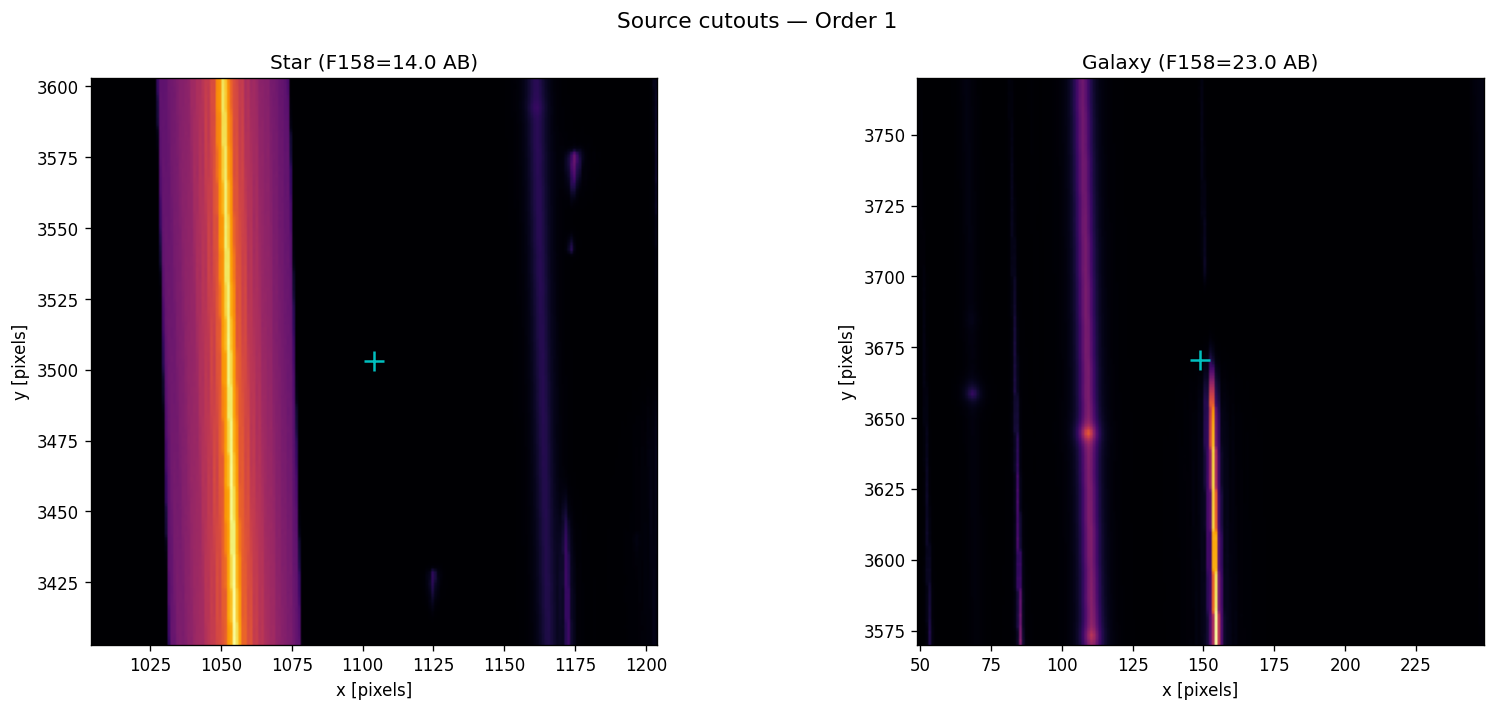

In [7]:
def plot_cutout(ax, image, xsca, ysca, half_size=100, **kwargs):
    """Plot a cutout centered on (xsca, ysca) in FITS 1-indexed coords."""
    # FITS 1-indexed to 0-indexed array
    xc = int(round(xsca)) - 1
    yc = int(round(ysca)) - 1
    y0 = max(0, yc - half_size)
    y1 = min(image.shape[0], yc + half_size)
    x0 = max(0, xc - half_size)
    x1 = min(image.shape[1], xc + half_size)
    cutout = image[y0:y1, x0:x1]
    
    vmax = cutout.max() if cutout.max() > 0 else 1.0
    norm = AsinhNorm(linear_width=0.01, vmin=0, vmax=vmax)
    ax.imshow(cutout, origin="lower", cmap="inferno", norm=norm,
              extent=[x0+1, x1+1, y0+1, y1+1], **kwargs)
    ax.plot(xsca, ysca, "c+", markersize=12, markeredgewidth=1.5)
    return cutout


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_cutout(axes[0], model, star_src["xsca"], star_src["ysca"])
axes[0].set_title(f"Star (F158={star_mag:.1f} AB)")

plot_cutout(axes[1], model, galaxy_src["xsca"], galaxy_src["ysca"])
axes[1].set_title(f"Galaxy (F158={galaxy_mag:.1f} AB)")

for ax in axes:
    ax.set_xlabel("x [pixels]")
    ax.set_ylabel("y [pixels]")

fig.suptitle(f"Source cutouts — Order {ORDER}", fontsize=13)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{OUTPUT_STEM}_cutouts.png", dpi=150)
plt.show()

## 6. Extracted 1D spectrum vs expected

For the selected star and galaxy:
1. Trace the beam position at each wavelength using the optical model
2. Sum flux in a cross-dispersion aperture at each wavelength step
3. Compare with input SED × sensitivity × dlam, corrected for dispersion

In [33]:
# Load optical model and sensitivity for spectrum extraction
_, sensitivity_dir, optical_model_path, _ = resolve_paths()
om = RomanOpticalModel(config_file=str(optical_model_path))
payload = omj.make_sca_payload(om, sca=SCA, order=ORDER)

wavelengths_um = np.linspace(0.9, 2.0, 5501).astype(np.float32)
dlam_um = float(wavelengths_um[1] - wavelengths_um[0])
dlam_angstroms = dlam_um * 1e4

sensitivities = load_sensitivities(sensitivity_dir, SCA, wavelengths_um)
sens = np.array(sensitivities[ORDER])

print(f"Wavelength grid: {wavelengths_um[0]:.2f} - {wavelengths_um[-1]:.2f} um, "
      f"{len(wavelengths_um)} samples")

Wavelength grid: 0.90 - 2.00 um, 5501 samples


In [34]:
# Load catalog to get the input SED
from scripts.build_grism_image import load_catalog, trim_wavelength_grid, load_galaxy_seds

catalog_dir, _, _, _ = resolve_paths()
meta_df, store, wavelengths_full = load_catalog(catalog_dir)
_, wl_mask, _ = trim_wavelength_grid(wavelengths_full)

In [35]:
def get_source_sed(src, meta_df, store, wl_mask):
    """Retrieve the input SED for a manifest source."""
    cat_idx = src["catalog_index"]
    row = meta_df.loc[cat_idx]
    flux_scale = row["flux_scale"]
    
    if src["type"] == "PSF":
        sed_idx = int(row["sed_index"])
        sed_full = np.array(store["star_seds"][sed_idx])
        sed = sed_full[wl_mask].astype(np.float32) * flux_scale
    else:
        sim_val = int(row["sim"])
        sed_idx = int(row["sed_index"])
        key = f"galaxy_seds/sim_{sim_val:03d}"
        sed_full = np.array(store[key][sed_idx])
        sed = sed_full[wl_mask].astype(np.float32) * flux_scale
    
    return sed


star_sed = get_source_sed(star_src, meta_df, store, wl_mask)
galaxy_sed = get_source_sed(galaxy_src, meta_df, store, wl_mask)
print(f"Star SED: shape={star_sed.shape}, total={star_sed.sum():.4e}")
print(f"Galaxy SED: shape={galaxy_sed.shape}, total={galaxy_sed.sum():.4e}")

Star SED: shape=(5501,), total=9.6121e-12
Galaxy SED: shape=(5501,), total=1.4573e-15


In [36]:
import jax


def trace_y_at_wavelength(payload, xsca, ysca, wavelength):
    """Scalar trace: returns y_sca as a function of scalar wavelength."""
    xfpa, yfpa = omj.sca_to_fpa(payload, xsca, ysca)
    wl = jnp.atleast_1d(wavelength)
    xfpa_arr = jnp.broadcast_to(xfpa, wl.shape)
    yfpa_arr = jnp.broadcast_to(yfpa, wl.shape)
    xmpa, ympa = omj.trace_beam(payload, xfpa_arr, yfpa_arr, wl)
    _, ty = omj.mpa_to_sca(payload, xmpa, ympa)
    return ty[0]


def extract_spectrum(image, payload, xsca, ysca, wavelengths_um, aperture=8):
    """Extract a 1D spectrum by summing cross-dispersion pixels along the trace.
    
    Dispersion is along y; extraction sums along x at each trace y position.
    Also computes dy/dlambda via JAX autodiff for dispersion scaling.
    
    Returns
    -------
    extracted : ndarray [N_wl]
    trace_x, trace_y : ndarray [N_wl]
    dy_dlam : ndarray [N_wl] — pixels per micron
    """
    xfpa, yfpa = omj.sca_to_fpa(payload, xsca, ysca)
    
    xmpa, ympa = omj.trace_beam(
        payload,
        jnp.broadcast_to(xfpa, (len(wavelengths_um),)),
        jnp.broadcast_to(yfpa, (len(wavelengths_um),)),
        jnp.array(wavelengths_um),
    )
    trace_x_all, trace_y_all = omj.mpa_to_sca(payload, xmpa, ympa)
    trace_x = np.array(trace_x_all).ravel()
    trace_y = np.array(trace_y_all).ravel()
    
    # Compute dy/dlambda via JAX autodiff
    dy_dlam_fn = jax.grad(lambda wl: trace_y_at_wavelength(payload, xsca, ysca, wl))
    dy_dlam_jit = jax.jit(jax.vmap(dy_dlam_fn))
    dy_dlam = np.array(dy_dlam_jit(jnp.array(wavelengths_um)))
    
    extracted = np.zeros(len(wavelengths_um))
    for i in range(len(wavelengths_um)):
        ix = int(round(trace_x[i])) - 1
        iy = int(round(trace_y[i])) - 1
        if ix < 0 or ix >= image.shape[1] or iy < 0 or iy >= image.shape[0]:
            continue
        x0 = max(0, ix - aperture)
        x1 = min(image.shape[1], ix + aperture + 1)
        extracted[i] = image[iy, x0:x1].sum()
    
    return extracted, trace_x, trace_y, dy_dlam


STAR_APERTURE = 8
GALAXY_APERTURE = 12

print(f"Extracting star spectrum (aperture=±{STAR_APERTURE} pix)...")
star_extracted, star_tx, star_ty, star_dy_dlam = extract_spectrum(
    model, payload, star_src["xsca"], star_src["ysca"], wavelengths_um,
    aperture=STAR_APERTURE,
)
print(f"  Dispersion: {np.abs(star_dy_dlam).mean():.1f} pixels/μm "
      f"({np.abs(star_dy_dlam).mean() * dlam_um:.3f} pixels/bin)")

print(f"Extracting galaxy spectrum (aperture=±{GALAXY_APERTURE} pix)...")
galaxy_extracted, gal_tx, gal_ty, gal_dy_dlam = extract_spectrum(
    model, payload, galaxy_src["xsca"], galaxy_src["ysca"], wavelengths_um,
    aperture=GALAXY_APERTURE,
)
print(f"  Dispersion: {np.abs(gal_dy_dlam).mean():.1f} pixels/μm "
      f"({np.abs(gal_dy_dlam).mean() * dlam_um:.3f} pixels/bin)")

Extracting star spectrum (aperture=±8 pix)...
  Dispersion: 934.4 pixels/μm (0.187 pixels/bin)
Extracting galaxy spectrum (aperture=±12 pix)...
  Dispersion: 932.1 pixels/μm (0.186 pixels/bin)


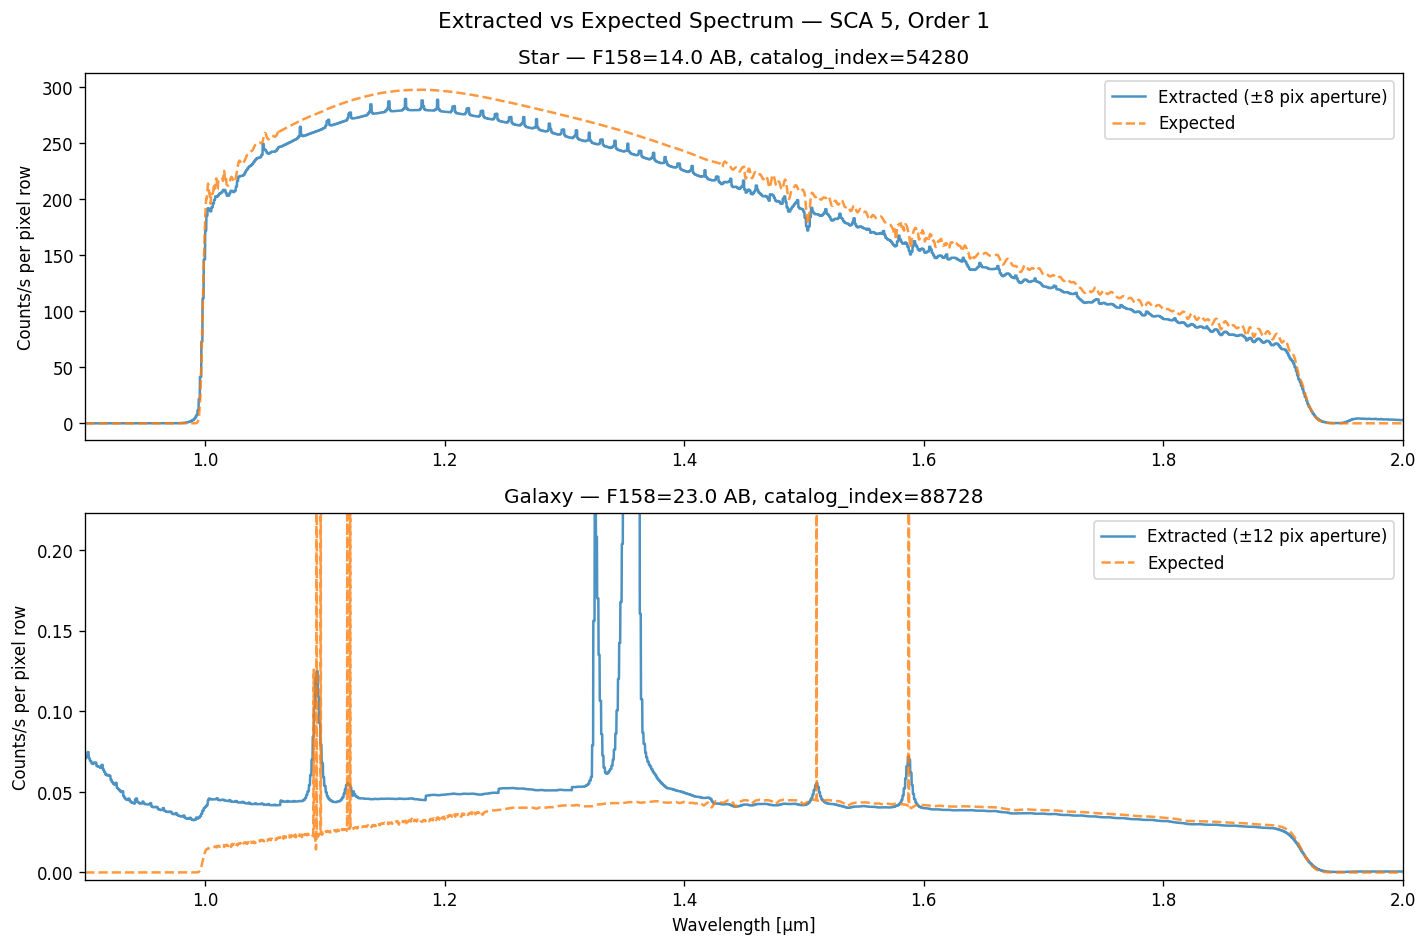

In [37]:
# Compute expected counts/s per pixel row:
#   (SED × sensitivity × dlam) / (|dy/dlam| × dlam_um)
# The denominator converts from per-wavelength-bin to per-pixel-row.

star_expected_per_pixel = (star_sed * sens * dlam_angstroms) / (np.abs(star_dy_dlam) * dlam_um)
galaxy_expected_per_pixel = (galaxy_sed * sens * dlam_angstroms) / (np.abs(gal_dy_dlam) * dlam_um)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Star — linear scale
ax = axes[0]
ax.plot(wavelengths_um, star_extracted,
        label=f"Extracted (±{STAR_APERTURE} pix aperture)", alpha=0.8)
ax.plot(wavelengths_um, star_expected_per_pixel,
        label="Expected", alpha=0.8, ls="--")
ax.set_ylabel("Counts/s per pixel row")
ax.set_title(f"Star — F158={star_mag:.1f} AB, "
             f"catalog_index={star_src['catalog_index']}")
ax.legend()
ax.set_xlim(0.9, 2.0)

# Galaxy — clip y-axis to continuum level (ignore emission line peaks)
ax = axes[1]
ax.plot(wavelengths_um, galaxy_extracted,
        label=f"Extracted (±{GALAXY_APERTURE} pix aperture)", alpha=0.8)
ax.plot(wavelengths_um, galaxy_expected_per_pixel,
        label="Expected", alpha=0.8, ls="--")
ax.set_ylabel("Counts/s per pixel row")
ax.set_xlabel("Wavelength [μm]")
ax.set_title(f"Galaxy — F158={galaxy_mag:.1f} AB, "
             f"catalog_index={galaxy_src['catalog_index']}")
# Set y-limit based on continuum (95th percentile to exclude emission lines)
continuum_level = np.percentile(galaxy_expected_per_pixel[galaxy_expected_per_pixel > 0], 95)
ax.set_ylim(-0.1 * continuum_level, 5 * continuum_level)
ax.legend()
ax.set_xlim(0.9, 2.0)

fig.suptitle(f"Extracted vs Expected Spectrum — SCA {SCA}, Order {ORDER}",
             fontsize=13)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{OUTPUT_STEM}_spectra.png", dpi=150)
plt.show()

## 7. Multi-source extraction gallery

Pick the 5 brightest isolated stars and 5 brightest isolated galaxies.
For each, show a cutout with trace overlay and extracted vs expected spectrum.

In [17]:
def find_n_bright_sources(manifest, source_type, order, cat_meta, n=5, min_sep=50):
    """Find the n brightest sources of a given type and order.
    
    Sorts by F158 magnitude (brightest first). Uses a relaxed isolation
    criterion — just avoids sources very close together.
    """
    subset = manifest[(manifest["type"] == source_type) &
                      (manifest["order"] == order)].copy()
    # Require source is well within the detector (trace won't go off-edge)
    subset = subset[(subset["xsca"] > 200) & (subset["xsca"] < 3888) &
                    (subset["ysca"] > 500) & (subset["ysca"] < 3588)]
    # Sort by F158 magnitude (lower = brighter)
    subset["F158"] = [cat_meta.loc[ci, "F158"] for ci in subset["catalog_index"]]
    subset = subset.sort_values("F158", ascending=True)

    found = []
    for _, candidate in subset.iterrows():
        cx, cy = candidate["xsca"], candidate["ysca"]
        too_close = any(
            np.sqrt((cx - s["xsca"])**2 + (cy - s["ysca"])**2) < min_sep
            for s in found
        )
        if not too_close:
            found.append(candidate)
            if len(found) == n:
                break

    if len(found) < n:
        print(f"  Only found {len(found)} {source_type} sources (requested {n})")
    return found


stars = find_n_bright_sources(manifest, "PSF", ORDER, cat_meta, n=5)
galaxies = find_n_bright_sources(manifest, "SER", ORDER, cat_meta, n=5)

print(f"Selected {len(stars)} stars, {len(galaxies)} galaxies")
for i, s in enumerate(stars):
    print(f"  Star {i}: xsca={s['xsca']:.0f}, ysca={s['ysca']:.0f}, F158={s['F158']:.1f}")
for i, g in enumerate(galaxies):
    print(f"  Galaxy {i}: xsca={g['xsca']:.0f}, ysca={g['ysca']:.0f}, F158={g['F158']:.1f}")

Selected 5 stars, 5 galaxies
  Star 0: xsca=972, ysca=540, F158=13.5
  Star 1: xsca=1104, ysca=3503, F158=14.0
  Star 2: xsca=1787, ysca=3160, F158=15.0
  Star 3: xsca=2118, ysca=2927, F158=15.5
  Star 4: xsca=891, ysca=2727, F158=15.5
  Galaxy 0: xsca=2032, ysca=2225, F158=21.5
  Galaxy 1: xsca=1167, ysca=2925, F158=21.6
  Galaxy 2: xsca=3690, ysca=901, F158=21.7
  Galaxy 3: xsca=2013, ysca=2112, F158=21.8
  Galaxy 4: xsca=1715, ysca=2211, F158=21.9


Plotting star gallery...


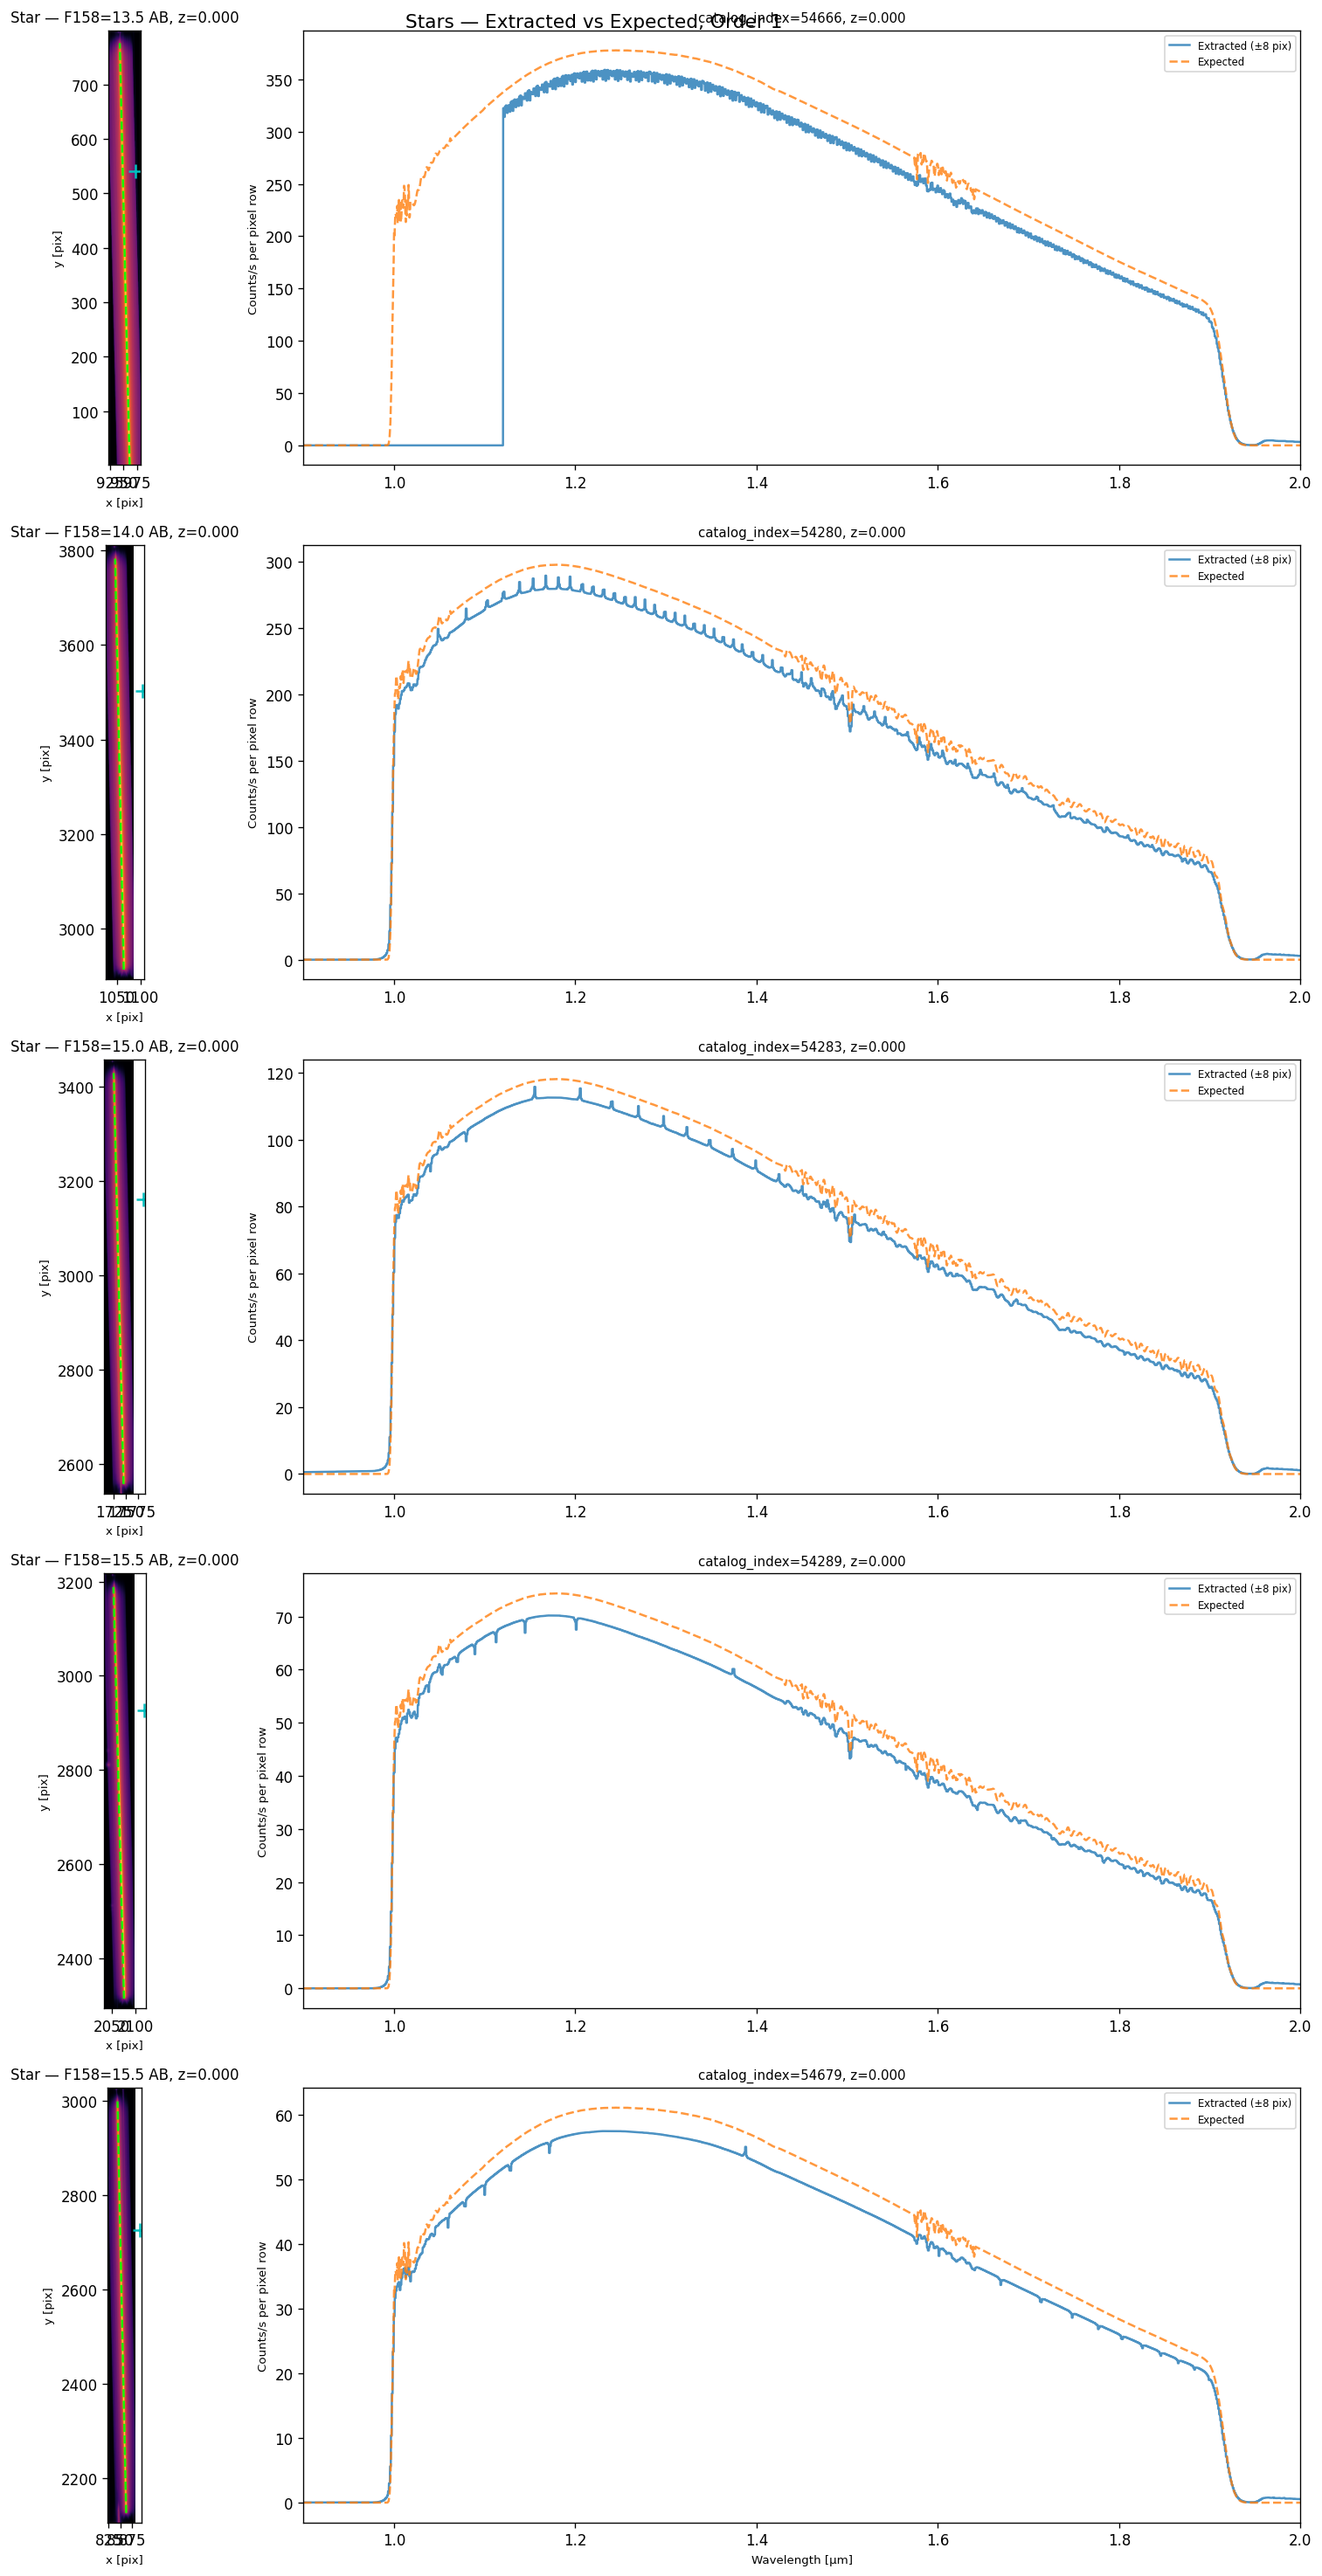

Plotting galaxy gallery...


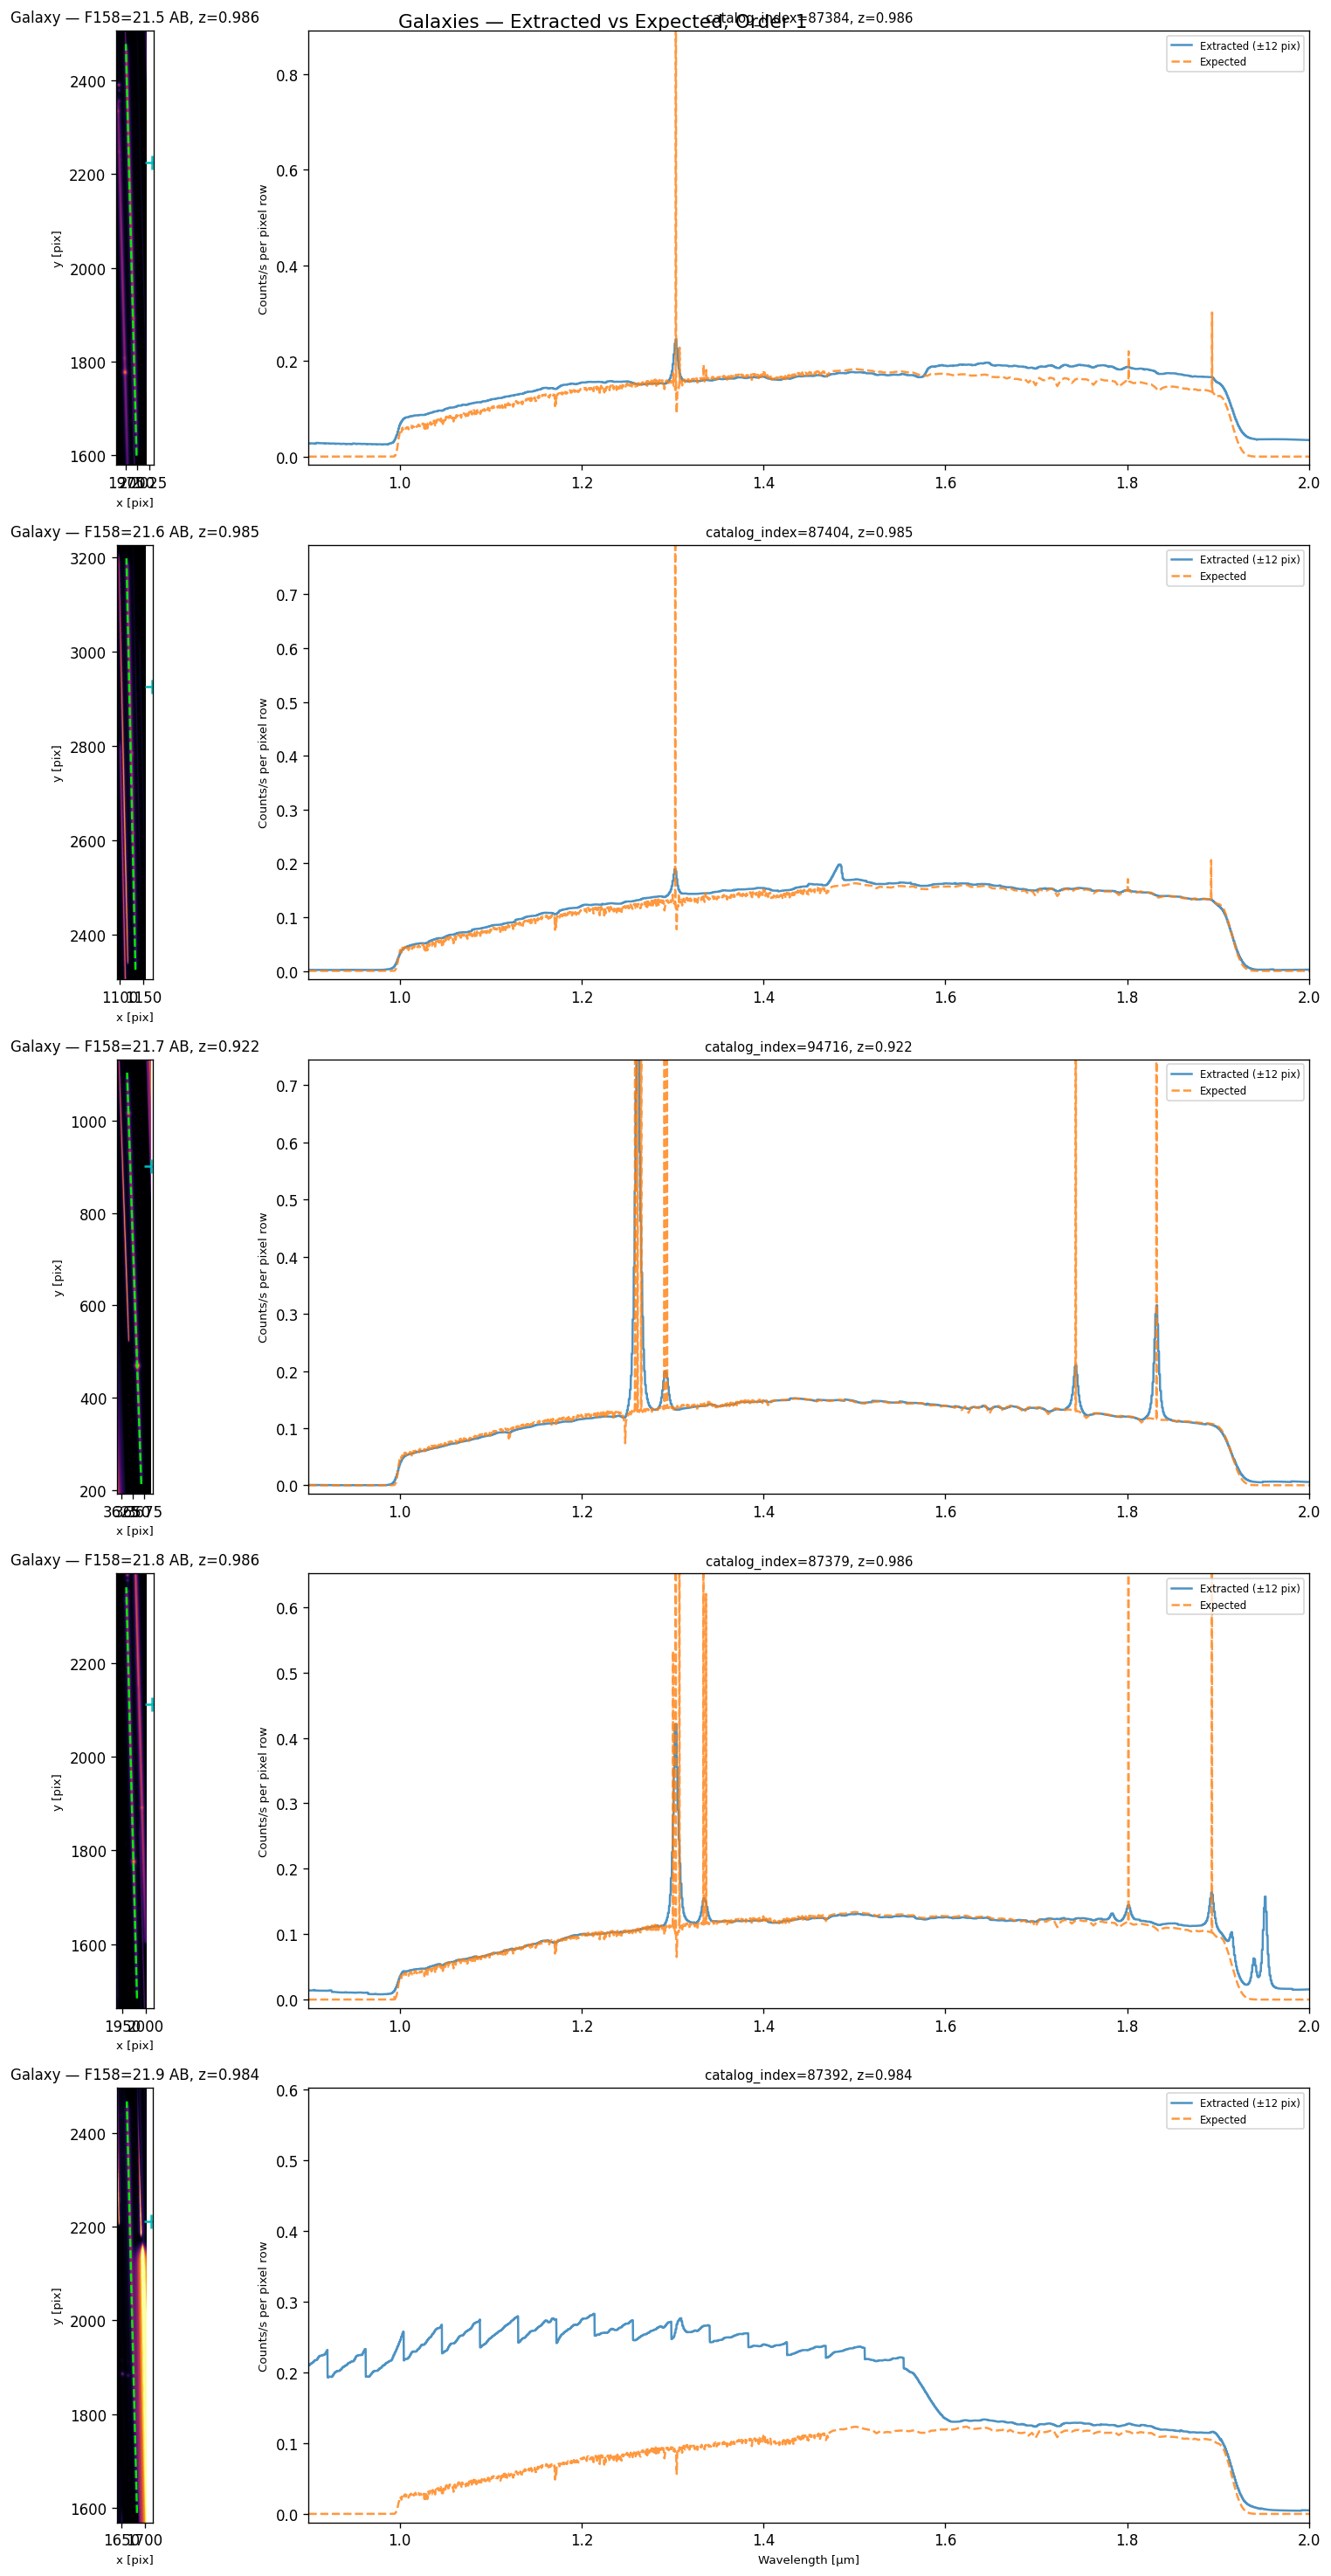

In [18]:
def plot_source_gallery(sources, source_type, filename):
    """Plot a gallery: cutout+trace (left) and spectrum (right) per source."""
    n = len(sources)
    fig, axes = plt.subplots(n, 2, figsize=(14, 5 * n),
                             gridspec_kw={"width_ratios": [1, 2]})
    if n == 1:
        axes = axes[np.newaxis, :]

    aperture = 8 if source_type == "PSF" else 12

    for i, src in enumerate(sources):
        mag = cat_meta.loc[src["catalog_index"], "F158"]
        z = cat_meta.loc[src["catalog_index"], "z_obs"]

        # Extract spectrum
        ext, tx, ty, dy_dl = extract_spectrum(
            model, payload, src["xsca"], src["ysca"], wavelengths_um,
            aperture=aperture,
        )

        # Get input SED and compute expected
        sed = get_source_sed(src, meta_df, store, wl_mask)
        expected = (sed * sens * dlam_angstroms) / (np.abs(dy_dl) * dlam_um)

        # -- Left panel: cutout with trace --
        ax_img = axes[i, 0]

        # Clip trace to in-band, on-detector
        in_band = sens > sens.max() * 0.01
        tx_b, ty_b = tx[in_band], ty[in_band]
        on_det = ((tx_b >= 1) & (tx_b <= 4088) &
                  (ty_b >= 1) & (ty_b <= 4088))
        tx_d, ty_d = tx_b[on_det], ty_b[on_det]

        if len(tx_d) > 0:
            pad_x, pad_y = 20, 20
            x0 = max(0, int(tx_d.min()) - 1 - pad_x)
            x1 = min(model.shape[1], int(tx_d.max()) + pad_x)
            y0 = max(0, int(ty_d.min()) - 1 - pad_y)
            y1 = min(model.shape[0], int(ty_d.max()) + pad_y)
            cutout = model[y0:y1, x0:x1]

            # Set stretch based on expected counts at 1.5 μm
            idx_15 = np.argmin(np.abs(wavelengths_um - 1.5))
            vmax = float(expected[idx_15]) if expected[idx_15] > 0 else 1.0
            norm = AsinhNorm(linear_width=0.01, vmin=0, vmax=vmax)
            ax_img.imshow(cutout, origin="lower", cmap="inferno", norm=norm,
                          extent=[x0+1, x1+1, y0+1, y1+1])
            ax_img.plot(tx_d[::50], ty_d[::50], color="lime", ls="--",
                        linewidth=1.5, alpha=0.9)
            ax_img.plot(src["xsca"], src["ysca"], "c+", markersize=10,
                        markeredgewidth=1.5)

        label = "Star" if source_type == "PSF" else "Galaxy"
        ax_img.set_title(f"{label} — F158={mag:.1f} AB, z={z:.3f}", fontsize=10)
        ax_img.set_xlabel("x [pix]", fontsize=8)
        ax_img.set_ylabel("y [pix]", fontsize=8)

        # -- Right panel: spectrum --
        ax_spec = axes[i, 1]
        ax_spec.plot(wavelengths_um, ext,
                     label=f"Extracted (±{aperture} pix)", alpha=0.8)
        ax_spec.plot(wavelengths_um, expected,
                     label="Expected", alpha=0.8, ls="--")
        ax_spec.set_xlim(0.9, 2.0)
        ax_spec.set_ylabel("Counts/s per pixel row", fontsize=8)
        ax_spec.legend(fontsize=7, loc="upper right")
        ax_spec.set_title(f"catalog_index={src['catalog_index']}, z={z:.3f}",
                          fontsize=9)

        if source_type == "SER":
            cont = np.percentile(expected[expected > 0], 95) if (expected > 0).any() else 1.0
            ax_spec.set_ylim(-0.1 * cont, 5 * cont)

        if i == n - 1:
            ax_spec.set_xlabel("Wavelength [μm]", fontsize=8)

    label = "Stars" if source_type == "PSF" else "Galaxies"
    fig.suptitle(f"{label} — Extracted vs Expected, Order {ORDER}", fontsize=13)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()


print("Plotting star gallery...")
plot_source_gallery(stars, "PSF", f"{OUTPUT_STEM}_star_gallery.png")

print("Plotting galaxy gallery...")
plot_source_gallery(galaxies, "SER", f"{OUTPUT_STEM}_galaxy_gallery.png")

## 8. Manifest sources on the focal plane

Plot manifest sources (from this SCA) on the WFI focal plane layout to verify
they fall within the correct detector footprint.

In [39]:
# Convert manifest RA/Dec to FPA coordinates
# Use unique sources only (each source appears once per order in manifest)
manifest_unique = manifest.drop_duplicates(subset=["catalog_index"])

manifest_xfpa, manifest_yfpa = omj.get_fpa_pos(
    jnp.array(manifest_unique["ra"].values),
    jnp.array(manifest_unique["dec"].values),
    POINTING_RA, POINTING_DEC, POINTING_PA,
)
manifest_xfpa_np = np.array(manifest_xfpa)
manifest_yfpa_np = np.array(manifest_yfpa)
manifest_types = manifest_unique["type"].values

print(f"Manifest: {len(manifest_unique)} unique sources "
      f"({(manifest_types == 'PSF').sum()} stars, "
      f"{(manifest_types == 'SER').sum()} galaxies)")

Manifest: 934 unique sources (811 stars, 123 galaxies)


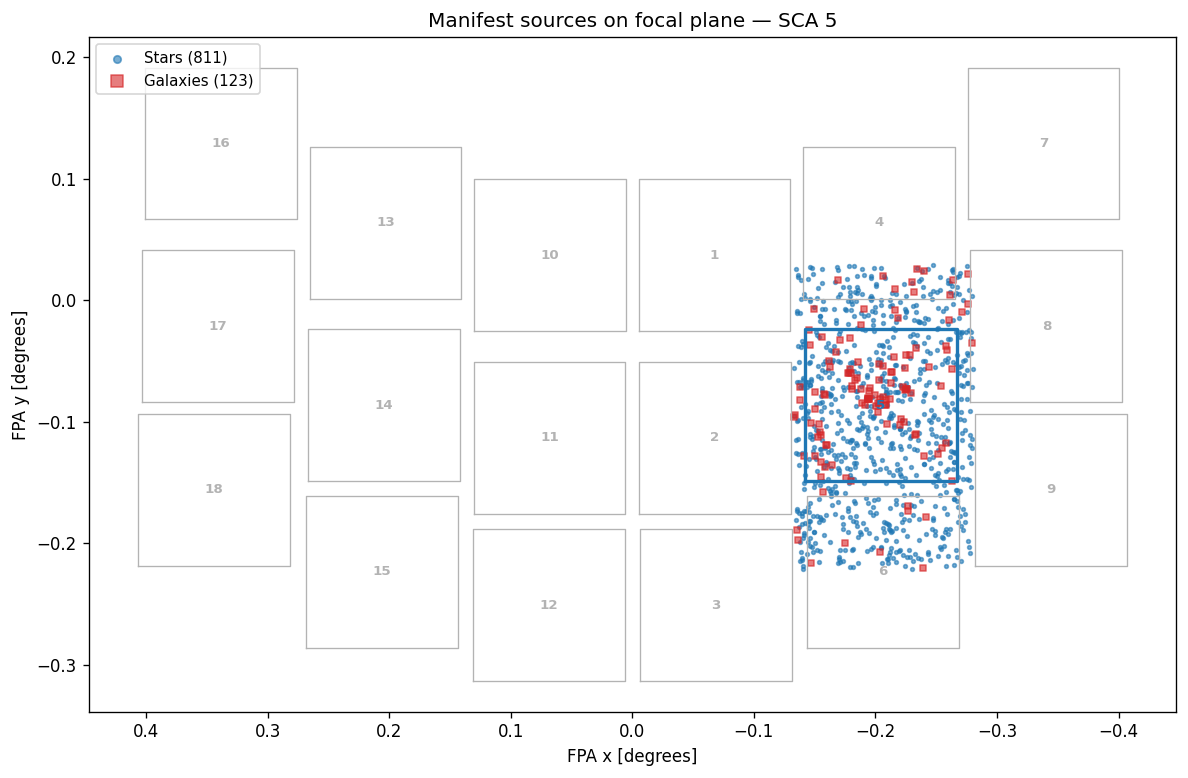

In [40]:
fig, ax = plt.subplots(figsize=(10, 10))

# Draw detector footprints for all 18 SCAs
all_payloads = {}
for sca_num in range(1, 19):
    all_payloads[sca_num] = omj.make_sca_payload(om, sca=sca_num, order="1")

for sca_num in range(1, 19):
    p = all_payloads[sca_num]
    corners_x = [1, 4088, 4088, 1, 1]
    corners_y = [1, 1, 4088, 4088, 1]
    fx, fy = omj.sca_to_fpa(p, jnp.array(corners_x, dtype=jnp.float32),
                                jnp.array(corners_y, dtype=jnp.float32))
    color = "C0" if sca_num == SCA else "0.7"
    lw = 2.0 if sca_num == SCA else 0.8
    ax.plot(np.array(fx), np.array(fy), color=color, linewidth=lw)
    cx, cy = omj.sca_to_fpa(p, 2044.5, 2044.5)
    ax.text(float(cx), float(cy), str(sca_num), ha="center", va="center",
            fontsize=8, color=color, fontweight="bold")

# Plot manifest sources color-coded by type
is_star_m = manifest_types == "PSF"
is_gal_m = manifest_types == "SER"
ax.scatter(manifest_xfpa_np[is_star_m], manifest_yfpa_np[is_star_m],
           s=5, c="C0", alpha=0.6, label=f"Stars ({is_star_m.sum()})")
ax.scatter(manifest_xfpa_np[is_gal_m], manifest_yfpa_np[is_gal_m],
           s=15, c="C3", marker="s", alpha=0.6, label=f"Galaxies ({is_gal_m.sum()})")

ax.set_xlabel("FPA x [degrees]")
ax.set_ylabel("FPA y [degrees]")
ax.set_title(f"Manifest sources on focal plane — SCA {SCA}")
ax.legend(loc="upper left", fontsize=9, markerscale=2)
ax.set_aspect("equal")
ax.invert_xaxis()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{OUTPUT_STEM}_fpa_sources.png", dpi=150)
plt.show()

## Summary

Saved diagnostic plots:
- `*_overview.png` — full detector MODEL and ISIM
- `*_cutouts.png` — bright star and galaxy cutouts
- `*_spectra.png` — extracted vs expected 1D spectra (dispersion-corrected)
- `*_star_gallery.png` — 5 bright stars: cutout + trace + spectrum
- `*_galaxy_gallery.png` — 5 bright galaxies: cutout + trace + spectrum
- `*_fpa_sources.png` — manifest sources on WFI focal plane layout